In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv('adj_close_data.csv', index_col='Date', parse_dates=True)
selected_stocks = ['AAPL', 'AMZN', 'JPM', 'DIS', 'TSLA']

feature_df = pd.DataFrame(index=df.index)
for stock in selected_stocks:
    feature_df[f'{stock}_MA10'] = df[stock].rolling(window=10).mean()
    feature_df[f'{stock}_MA50'] = df[stock].rolling(window=50).mean()
    feature_df[f'{stock}_MA200'] = df[stock].rolling(window=200).mean()
    feature_df[f'{stock}_Volatility'] = df[stock].rolling(window=10).std()
    feature_df[f'{stock}_Return'] = np.log(df[stock] / df[stock].shift(1))

feature_df.dropna(inplace=True)
target_stock = 'AAPL'
X = feature_df[[f'{target_stock}_MA10', f'{target_stock}_MA50', f'{target_stock}_MA200', f'{target_stock}_Volatility']]
y = feature_df[f'{target_stock}_Return']


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

lr = LinearRegression().fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

svm = SVR(kernel='rbf').fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

nn = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42).fit(X_train_scaled, y_train)
nn_pred = nn.predict(X_test_scaled)


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

models = ['Linear Regression', 'SVM', 'Random Forest', 'Neural Network']
predictions = [lr_pred, svm_pred, rf_pred, nn_pred]

results = {'Model': [], 'MSE': [], 'MAE': [], 'R²': []}
for name, pred in zip(models, predictions):
    results['Model'].append(name)
    results['MSE'].append(mean_squared_error(y_test, pred))
    results['MAE'].append(mean_absolute_error(y_test, pred))
    results['R²'].append(r2_score(y_test, pred))

results_df = pd.DataFrame(results)
print(results_df)


               Model       MSE       MAE        R²
0  Linear Regression  0.000349  0.013712 -0.049518
1                SVM  0.001574  0.036121 -3.731065
2      Random Forest  0.000388  0.015092 -0.165131
3     Neural Network  0.001456  0.031012 -3.374397


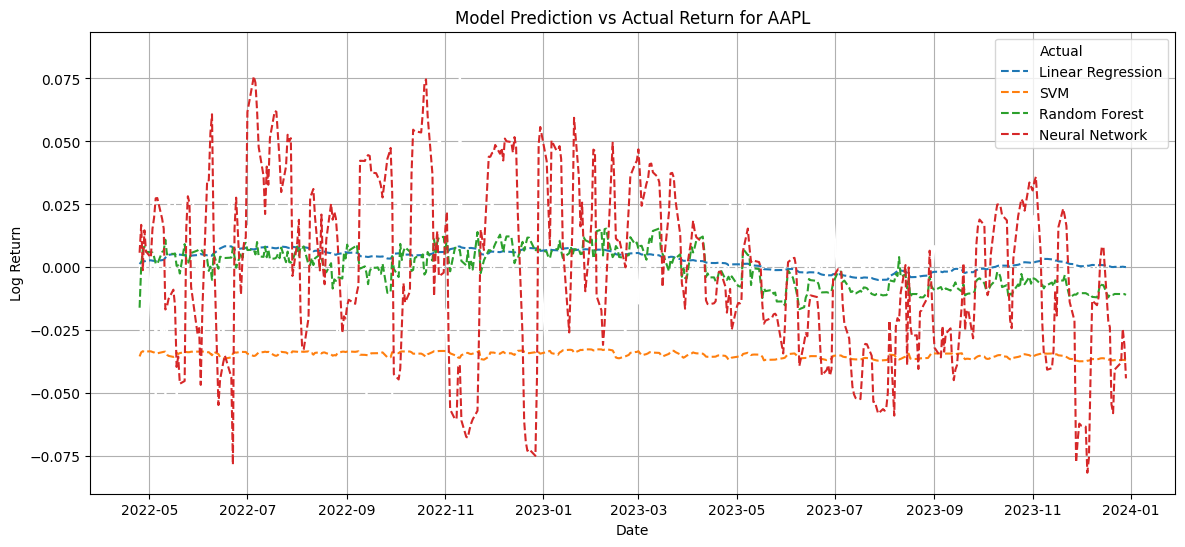

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Actual', color='white')
plt.plot(y_test.index, lr_pred, label='Linear Regression', linestyle='--')
plt.plot(y_test.index, svm_pred, label='SVM', linestyle='--')
plt.plot(y_test.index, rf_pred, label='Random Forest', linestyle='--')
plt.plot(y_test.index, nn_pred, label='Neural Network', linestyle='--')

plt.legend()
plt.title(f'Model Prediction vs Actual Return for {target_stock}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)
plt.show()


In [22]:
from sklearn.model_selection import GridSearchCV

# SVM
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}
svm_grid = GridSearchCV(SVR(), svm_params, cv=5, scoring='neg_mean_squared_error')
svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_
print("✅ Best SVM:", svm_grid.best_params_)

# Random Forest
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 5], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='neg_mean_squared_error')
rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_
print("✅ Best Random Forest:", rf_grid.best_params_)

# Neural Network
nn_params = {
    'hidden_layer_sizes': [(64,), (128, 64), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'max_iter': [1000],
    'early_stopping': [True]
}
nn_grid = GridSearchCV(MLPRegressor(random_state=42), nn_params, cv=3, scoring='neg_mean_squared_error')
nn_grid.fit(X_train_scaled, y_train)
best_nn_params = nn_grid.best_params_
print("✅ Best Neural Network (structure):", best_nn_params)

from sklearn.neural_network import MLPRegressor
nn_best = MLPRegressor(
    hidden_layer_sizes=best_nn_params['hidden_layer_sizes'],
    activation=best_nn_params['activation'],
    max_iter=1000,
    early_stopping=True,
    tol=1e-4,
    random_state=42
)
nn_best.fit(X_train_scaled, y_train)
nn_pred_best = nn_best.predict(X_test_scaled)


✅ Best SVM: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
✅ Best Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
✅ Best Neural Network (structure): {'activation': 'tanh', 'early_stopping': True, 'hidden_layer_sizes': (128, 64, 32), 'max_iter': 1000}


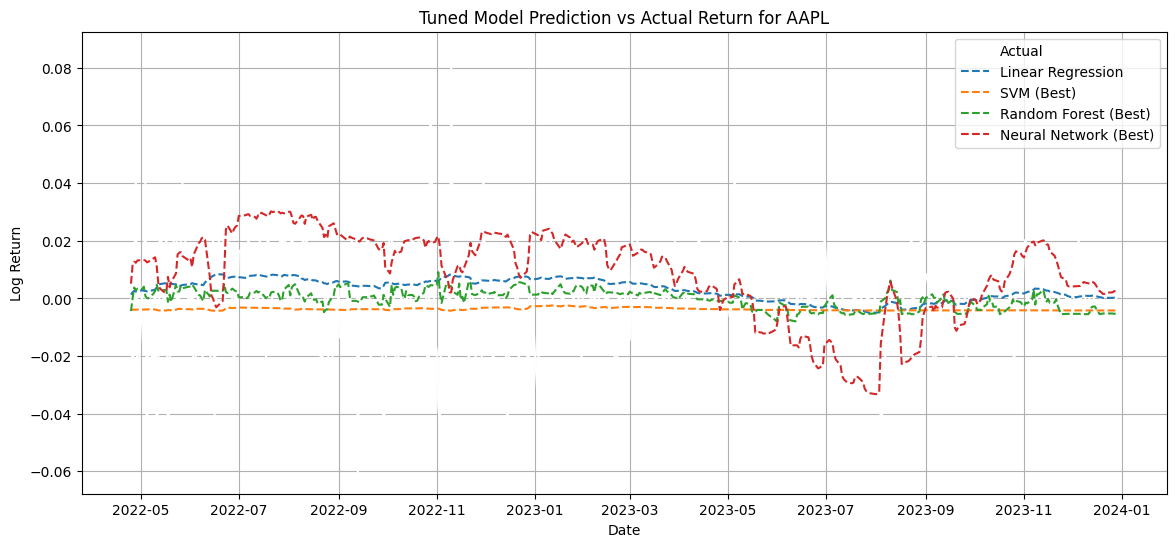

In [23]:
# 使用最佳 SVM 和 RF 预测
svm_pred_best = svm_best.predict(X_test_scaled)
rf_pred_best = rf_best.predict(X_test_scaled)

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Actual', color='white')
plt.plot(y_test.index, lr_pred, label='Linear Regression', linestyle='--')
plt.plot(y_test.index, svm_pred_best, label='SVM (Best)', linestyle='--')
plt.plot(y_test.index, rf_pred_best, label='Random Forest (Best)', linestyle='--')
plt.plot(y_test.index, nn_pred_best, label='Neural Network (Best)', linestyle='--')

plt.legend()
plt.title(f'Tuned Model Prediction vs Actual Return for {target_stock}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)
plt.show()